# GRU + cross-attention recipe reranker

Implements [recipe_reranker_spec.md](recipe_reranker_spec.md). Given a user's rating history and one candidate
recipe from the upstream retrieval stage, the model predicts **P(the user rates it positively)**.

The user is not compressed into one vector. Tastes drift, so the history is cut into time windows: a window ends
where the user goes 6 months or more without rating. The GRU runs over each window from a fresh state, and the
candidate attends over a static profile token and the final GRU state of each recent window. Each part of the model is its own class, as in the spec:

```text
ItemEncoder      product / adj / verb tokens ─► embedding ─► self-attention ─► mean pool ─► text_emb ─┐
                 [price, nutrients] (log1p, z-score) ─► Linear ─────────────────────────► num_emb ──┴─► Linear(2d, d) ─► item_emb

HistoryEncoder   history before t, split into windows wherever the gap between two ratings is >= 6 months
                 (last max_windows windows, last t_max recipes each, date order inside a window)
                 item_emb + Linear(centered rating) ─► GRU, restarted per window ─► final state per window
                 ─► w_1 … w_K (+ recency embedding, w_1 = most recent) ────────────────────────────┐
UserEncoder      avg price + avg nutrients before t ─► standardize ─► MLP ─► U_profile ────────────┴─► keys / values (1+K, d)

GRUCrossAttentionReranker
                 candidate item_emb ─► query ─► MultiheadAttention ─► attn_out
                 MLP(concat(attn_out, item_emb)) ─► logit ─► sigmoid ─► P(positive)
```

**Where the spec leaves a choice**

| Spec point | Choice made here |
|---|---|
| 1.6 `negative_sampling_power` | 1: sampled negatives are drawn ∝ popularity (ratings in the whole file), so preferring popular recipes does not separate the classes. |
| 2.1 pooling and fusion | Mean pooling with the padding mask; fusion option A; the field embedding is on. |
| 2.2 profile module | Two-layer MLP. |
| 2.3 history rating | `Linear(1, d)` of the centered rating (rating − mean rating before t, not scaled), added to the step's `item_emb`. |
| 2.3 history windows | A gap of `window_gap_days` (183, about 6 months) or more between consecutive ratings starts a new window. The GRU restarts per window; its final state is the window's key. The last `max_windows` windows are kept, each with its last `t_max` recipes. A learned embedding of the window's recency (0 = most recent) is added to its key. |
| 3.2 optimizer | AdamW; early stopping on validation log loss. |

In [1]:
%pip install pandas numpy torch nltk matplotlib tqdm ipywidgets


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from dataclasses import asdict, dataclass
from functools import lru_cache
import json
import math
from pathlib import Path
import random
import re
import time

import matplotlib.pyplot as plt
import nltk
from nltk.stem import WordNetLemmatizer
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import nn
from torch.nn import functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from tqdm.auto import tqdm


@dataclass(frozen=True)
class RerankerConfig:
    seed: int = 42
    max_users: int | None = None          # A random subset of users for a quick run; None keeps everyone.
    positive_min_rating: int = 3          # 3-5 positive, 0-2 negative (spec 1.2).
    min_user_ratings: int = 6             # Spec 1.3.
    negative_sampling_power: float = 1.0  # Sampled negatives ∝ popularity ** power; 0 is uniform.
    min_token_count: int = 3              # Tokens in fewer training recipes map to <unk>.
    max_tokens: int = 40                  # Tokens kept per recipe (p99 is 31).
    d: int = 64
    n_heads: int = 4
    text_layers: int = 1
    t_max: int = 20                       # Most recent recipes of each window fed to the GRU.
    max_windows: int = 10                 # Most recent history windows kept (one attention key each).
    window_gap_days: int = 183            # A gap this long (about 6 months) or longer between ratings starts a window.
    dropout: float = 0.1                  # Cross-attention and head.
    text_dropout: float = 0.0             # Inside the token self-attention: on CPU it costs more than the rest of a step.
    lr: float = 1e-3
    weight_decay: float = 1e-5
    batch_size: int = 512
    chunk_size: int = 16                  # Consecutive rows of one user kept together in a batch.
    max_epochs: int = 10
    patience: int = 2                     # Epochs without a validation log-loss improvement before stopping.
    ranking_negatives: int = 99
    ndcg_k: int = 10


CONFIG = RerankerConfig()

NUTRIENT_COLUMNS = ["calories (g)", "total fat (g)", "sugar (g)", "sodium (g)", "protein (g)",
                    "saturated fat (g)", "carbohydrates (g)"]
PRICE_COLUMN = "total_prices"
TEXT_FIELDS = {"product": ("n", 1), "adj": ("a", 2), "verb": ("v", 3)}  # WordNet part of speech, field id.
POSITIVE, RATED_NEGATIVE, SAMPLED_NEGATIVE = "positive (3-5)", "rated negative (0-2)", "sampled negative"

random.seed(CONFIG.seed)
np.random.seed(CONFIG.seed)
torch.manual_seed(CONFIG.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(asdict(CONFIG))

Device: cpu
{'seed': 42, 'max_users': None, 'positive_min_rating': 3, 'min_user_ratings': 6, 'negative_sampling_power': 1.0, 'min_token_count': 3, 'max_tokens': 40, 'd': 64, 'n_heads': 4, 'text_layers': 1, 't_max': 20, 'max_windows': 10, 'window_gap_days': 183, 'dropout': 0.1, 'text_dropout': 0.0, 'lr': 0.001, 'weight_decay': 1e-05, 'batch_size': 512, 'chunk_size': 16, 'max_epochs': 10, 'patience': 2, 'ranking_negatives': 99, 'ndcg_k': 10}


In [3]:
import pandas as pd

ARTIFACT_DIR = Path(
    "./model_artifacts/gru_xattn_reranker"
)
INPUT_DIR = "./input_stage2"

recipe_user_interaction_df = pd.read_csv(INPUT_DIR+"/recipe_user_ratings_prices.csv")

## Phase 1: Preprocessing and profiling

### 1.1 Text normalization

Each word of `product`, `adj` and `verb` is lowercased and stripped of punctuation (a hyphen splits words:
`hard-boiled` → `hard boiled`). It is then lemmatized with WordNet using its column's part of speech (`ground` as
a verb → `grind`) and singularized with WordNet's noun lemmatizer. WordNet only rewrites plurals it knows, so
`hummus`, `couscous` and `molasses` survive; suffix rules would cut them. Each (token, field) pair is kept once
per recipe, in order.

In [4]:
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
_lemmatizer = WordNetLemmatizer()
_NON_ALPHANUMERIC = re.compile(r"[^a-z0-9]+")


@lru_cache(maxsize=None)
def normalize_word(word, pos):
    """Lemmatize with the column's part of speech, then singularize (WordNet noun lemma)."""
    return _lemmatizer.lemmatize(_lemmatizer.lemmatize(word, pos), "n")


def recipe_tokens(product, adj, verb):
    """(token, field id) pairs of one recipe, in order, each kept once."""
    tokens = {}
    for (pos, field), raw in zip(TEXT_FIELDS.values(), (product, adj, verb)):
        for ingredient in json.loads(raw):
            for phrase in ingredient:
                for word in _NON_ALPHANUMERIC.sub(" ", phrase.lower()).split():
                    tokens.setdefault((normalize_word(word, pos), field), None)
    return list(tokens)


# Recipe columns are constant per recipe_id, so one row per recipe is the catalog.
recipes = (recipe_user_interaction_df
           .drop_duplicates("recipe_id")[["recipe_id", "name", *NUTRIENT_COLUMNS, PRICE_COLUMN, *TEXT_FIELDS]]
           .sort_values("recipe_id").reset_index(drop=True))
recipes["tokens"] = [recipe_tokens(*row) for row in recipes[list(TEXT_FIELDS)].itertuples(index=False)]
recipe_index = pd.Series(recipes.index, index=recipes["recipe_id"])
token_counts = recipes["tokens"].str.len()
print(f"{len(recipes):,} recipes; tokens per recipe: median {token_counts.median():.0f}, "
      f"p99 {token_counts.quantile(0.99):.0f}, max {token_counts.max()}")
display(recipes[["recipe_id", "name", *TEXT_FIELDS, "tokens"]].head(3))

99,763 recipes; tokens per recipe: median 14, p99 31, max 56


,recipe_id,name,product,adj,verb,tokens
0,38,low fat berry blue frozen dessert,"[[""blueberry""], [""granulated sugar""], [""yogurt...","[[], [], [""vanilla""], []]","[[], [], [], []]","[(blueberry, 1), (granulated, 1), (sugar, 1), ..."
1,41,carina s tofu vegetable kebabs,"[[""tofu""], [""eggplant""], [""zucchini""], [""peppe...","[[""extra"", ""extra firm""], [], [], [""red""], [],...","[[], [], [], [], [], [], [], [], [], [], [], [...","[(tofu, 1), (eggplant, 1), (zucchini, 1), (pep..."
2,45,buttermilk pie with gingersnap crumb crust,"[[""sugar""], [""margarine""], [""egg""], [""egg whit...","[[], [], [], [], [], [], [], [], [""crumbs""]]","[[], [], [], [], [], [], [], [], []]","[(sugar, 1), (margarine, 1), (egg, 1), (white,..."


### 1.2–1.4 Labels, activity filter and rating centering

Ratings 3–5 are positive, 0–2 negative. Users with fewer than 6 observed ratings are dropped, then `mu_user` and
`rating_centered` are computed on the rows that remain. In Food.com a rating of 0 usually means a review without
stars; the spec counts it as negative, and so does this notebook.

In [5]:
interactions = recipe_user_interaction_df[["user_id", "recipe_id", "rating", "date"]].copy()
interactions["date"] = pd.to_datetime(interactions["date"])
interactions["label"] = (interactions["rating"] >= CONFIG.positive_min_rating).astype(np.int8)

ratings_per_user = interactions.groupby("user_id").size()
active_users = ratings_per_user.index[ratings_per_user >= CONFIG.min_user_ratings]
if CONFIG.max_users is not None and len(active_users) > CONFIG.max_users:
    active_users = np.random.default_rng(CONFIG.seed).choice(active_users, CONFIG.max_users, replace=False)
observed = (interactions[interactions["user_id"].isin(active_users)]
            .sort_values(["user_id", "date", "recipe_id"]).reset_index(drop=True))
observed["recipe_idx"] = recipe_index.loc[observed["recipe_id"]].to_numpy()
observed["source"] = np.where(observed["label"] == 1, POSITIVE, RATED_NEGATIVE)
# The filter drops whole users, so this is each kept user's mean either way. Only profiled below: the model
# never sees it.
observed["mu_user"] = observed.groupby("user_id")["rating"].transform("mean")
observed["rating_centered"] = observed["rating"] - observed["mu_user"]
print(f"Activity filter kept {observed['user_id'].nunique():,} of {interactions['user_id'].nunique():,} users "
      f"and {len(observed):,} of {len(interactions):,} ratings")
display(observed.groupby("rating").agg(rows=("label", "size"), label=("label", "first")).T)

Activity filter kept 10,450 of 126,032 users and 356,422 of 512,614 ratings


rating,0,1,2,3,4,5
rows,8031,1531,3367,13225,66667,263601
label,0,0,0,1,1,1


### 1.5 Split and 1.6 negative sampling

The split comes first so that each sampled negative can inherit its positive's split. Each user's observed ratings
are ordered by date (recipe id breaks ties): the last is test, the second-to-last validation, the rest train. Then
every positive gets one recipe that user never rated, drawn ∝ popularity (ratings in the whole file), with label 0 and the
positive's date. Draws for one user are distinct. A sampled negative has no rating: 0 already means an observed
negative, so its `rating`, `mu_user` and `rating_centered` stay empty.

In [6]:
from_end = observed.groupby("user_id").cumcount(ascending=False)
observed["split"] = np.select([from_end == 0, from_end == 1], ["test", "validation"], "train")

# Ratings per recipe in the whole file: a sampling distribution only, never a model input (spec 1.6).
popularity = np.bincount(recipe_index.loc[interactions["recipe_id"]].to_numpy(), minlength=len(recipes))
sampling_weights = popularity.astype(np.float64) ** CONFIG.negative_sampling_power
sampling_weights /= sampling_weights.sum()
rated_pairs = pd.MultiIndex.from_arrays([observed["user_id"], observed["recipe_idx"]])


def sample_unrated(user_ids, rng):
    """One recipe index per entry of user_ids, drawn ∝ sampling_weights among recipes that user never rated.
    Draws for the same user are distinct."""
    sampled = rng.choice(len(recipes), size=len(user_ids), p=sampling_weights)
    while True:
        pairs = pd.MultiIndex.from_arrays([user_ids, sampled])
        clash = pairs.isin(rated_pairs) | pairs.duplicated()
        if not clash.any():
            return sampled
        sampled[clash] = rng.choice(len(recipes), size=int(clash.sum()), p=sampling_weights)


sampled = observed.loc[observed["label"] == 1, ["user_id", "date", "split"]].copy()
sampled["recipe_idx"] = sample_unrated(sampled["user_id"].to_numpy(), np.random.default_rng(CONFIG.seed))
sampled["recipe_id"] = recipes["recipe_id"].to_numpy()[sampled["recipe_idx"]]
sampled["label"] = np.int8(0)  # No rating, mu_user or rating_centered: they stay NaN (spec 1.6).
sampled["source"] = SAMPLED_NEGATIVE
# Every (user, recipe) pair is unique here, so this order is deterministic.
examples = (pd.concat([observed, sampled], ignore_index=True)
            .sort_values(["user_id", "date", "recipe_idx"]).reset_index(drop=True))
print(f"{len(examples):,} (user, recipe) rows: {len(observed):,} observed and {len(sampled):,} sampled negatives; "
      f"positive share {examples['label'].mean():.1%}")

699,915 (user, recipe) rows: 356,422 observed and 343,493 sampled negatives; positive share 49.1%


### 1.7 Profiling plots

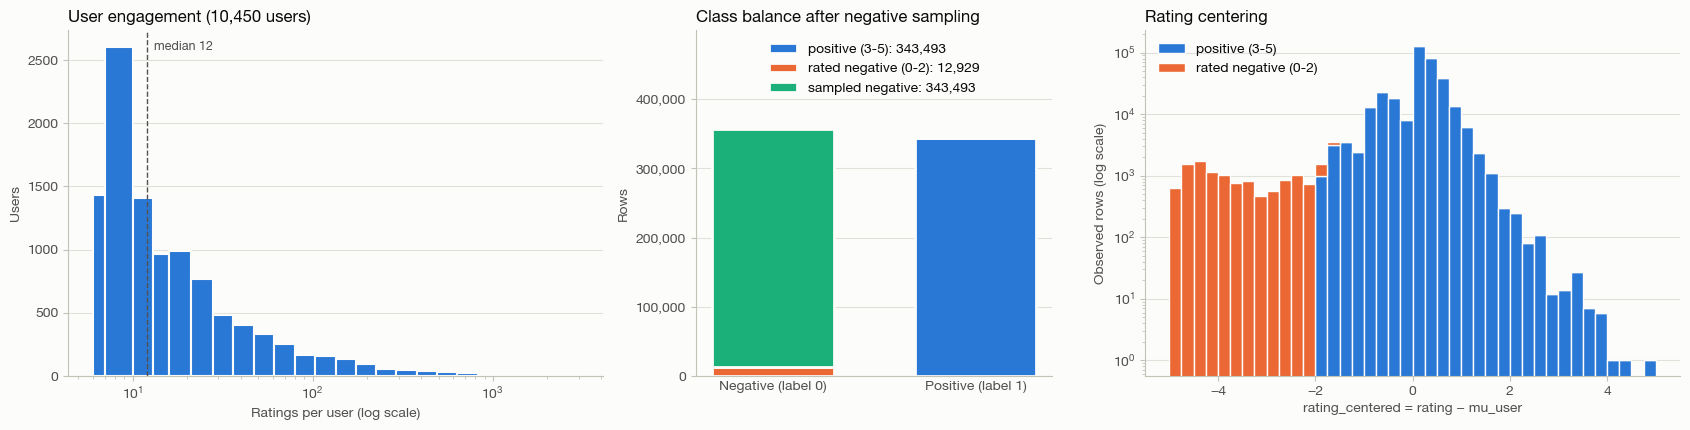

,rows,label,share
source,,,
positive (3-5),343493,1,0.491
rated negative (0-2),12929,0,0.018
sampled negative,343493,0,0.491


In [7]:
SURFACE, INK, INK_2, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
VIZ_STYLE = {
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlecolor": INK,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
}
SOURCE_COLORS = {POSITIVE: BLUE, RATED_NEGATIVE: ORANGE, SAMPLED_NEGATIVE: AQUA}

ratings_per_active_user = observed.groupby("user_id").size()
source_counts = examples["source"].value_counts()
with plt.rc_context(VIZ_STYLE):
    fig, (engagement_ax, balance_ax, centered_ax) = plt.subplots(1, 3, figsize=(17, 4.4),
                                                                 width_ratios=[1.2, 0.8, 1.2])
    user_bins = np.unique(np.geomspace(CONFIG.min_user_ratings, ratings_per_active_user.max() + 1, 25).astype(int))
    engagement_ax.hist(ratings_per_active_user, bins=user_bins, color=BLUE, edgecolor=SURFACE, linewidth=1.5)
    engagement_ax.set_xscale("log")
    median_ratings = ratings_per_active_user.median()
    engagement_ax.axvline(median_ratings, color=INK_2, linewidth=1, linestyle="--")
    engagement_ax.annotate(f"median {median_ratings:.0f}", (median_ratings, 1), xycoords=("data", "axes fraction"),
                           xytext=(5, -14), textcoords="offset points", color=INK_2, fontsize=9)
    engagement_ax.set(xlabel="Ratings per user (log scale)", ylabel="Users",
                      title=f"User engagement ({len(ratings_per_active_user):,} users)")
    engagement_ax.grid(axis="x", visible=False)

    # Rows per label, stacked by where the row comes from.
    bottom = np.zeros(2)
    for source, color in SOURCE_COLORS.items():
        counts = (examples.loc[examples["source"] == source, "label"].value_counts()
                  .reindex([0, 1], fill_value=0).to_numpy())
        balance_ax.bar([0, 1], counts, bottom=bottom, width=0.6, color=color, edgecolor=SURFACE, linewidth=2,
                       label=f"{source}: {source_counts.get(source, 0):,}")
        bottom += counts
    balance_ax.set_xticks([0, 1], ["Negative (label 0)", "Positive (label 1)"])
    balance_ax.set_ylim(0, bottom.max() * 1.4)  # Room for the legend above the bars.
    balance_ax.set(ylabel="Rows", title="Class balance after negative sampling")
    balance_ax.yaxis.set_major_formatter("{x:,.0f}")
    balance_ax.tick_params(axis="x", length=0)
    balance_ax.grid(axis="x", visible=False)
    balance_ax.legend(frameon=False, loc="upper center")

    # Observed rows only: sampled negatives have no rating.
    low, high = observed["rating_centered"].min(), observed["rating_centered"].max()
    centered_bins = np.arange(np.floor(low * 4) / 4, high + 0.25, 0.25)
    centered_ax.hist([observed.loc[observed["source"] == source, "rating_centered"]
                      for source in (POSITIVE, RATED_NEGATIVE)],
                     bins=centered_bins, stacked=True, color=[BLUE, ORANGE], edgecolor=SURFACE, linewidth=1,
                     label=[POSITIVE, RATED_NEGATIVE])
    centered_ax.set_yscale("log")
    centered_ax.set(xlabel="rating_centered = rating − mu_user", ylabel="Observed rows (log scale)",
                    title="Rating centering")
    centered_ax.grid(axis="x", visible=False)
    centered_ax.legend(frameon=False, loc="upper left")
    fig.tight_layout()
    plt.show()

balance = examples.groupby("source").agg(rows=("label", "size"), label=("label", "first"))
balance["share"] = balance["rows"] / balance["rows"].sum()
display(balance.loc[list(SOURCE_COLORS)].round(3))

## Phase 2: Examples, normalization and history

Each row of `examples` is one (user, candidate recipe) pair at day t. Its history is the user's observed ratings
on days **strictly before** t (constraint 1). All of them feed the profile. For the GRU they are cut into
**windows**: a new window starts wherever the next rating comes `window_gap_days` (about 6 months) or more after
the previous one, because tastes can change over such a gap. The last `max_windows` windows are kept, each with its
last `t_max` recipes. Each history step also carries its rating, centered on the user's mean rating over those
earlier days (not scaled). Rows with no earlier day (each user's first day) are dropped. The token vocabulary, the
item [price, nutrients] z-score and the profile z-score are all fit on training rows only (constraint 3).

Windows are built per batch in `to_batch` from each row's slice of `observed`, so the (rows × windows × steps)
arrays are never materialized for the whole data set.

In [8]:
users = pd.Index(observed["user_id"].unique())
DAY_SPAN = 1 << 20  # Day numbers stay below this, so user * DAY_SPAN + day sorts by user, then day.


def user_day_keys(frame):
    days = frame["date"].to_numpy().astype("datetime64[D]").astype(np.int64)
    return users.get_indexer(frame["user_id"]).astype(np.int64) * DAY_SPAN + days


observed_keys = user_day_keys(observed)  # Ascending: observed is sorted by user, then date.
example_keys = user_day_keys(examples)
user_start = np.searchsorted(observed_keys, example_keys - example_keys % DAY_SPAN)
prior_end = np.searchsorted(observed_keys, example_keys)  # First observed rating on or after the row's day.
n_prior = prior_end - user_start
has_history = n_prior > 0
print(f"Dropped {(~has_history).sum():,} rows with no earlier day of history")
examples = examples[has_history].reset_index(drop=True)
user_start, prior_end, n_prior = user_start[has_history], prior_end[has_history], n_prior[has_history]
split = examples["split"].to_numpy()

# Vocabulary from recipes in training rows (targets, sampled negatives and, through them, histories).
train_recipes = np.unique(examples.loc[split == "train", "recipe_idx"])
token_recipe_counts = pd.Series([token for tokens in recipes["tokens"].iloc[train_recipes]
                                 for token in dict.fromkeys(token for token, _ in tokens)]).value_counts()
vocabulary = ["<pad>", "<unk>", *sorted(token_recipe_counts.index[token_recipe_counts >= CONFIG.min_token_count])]
token_lookup = {token: index for index, token in enumerate(vocabulary)}
token_ids = np.zeros((len(recipes), CONFIG.max_tokens), dtype=np.int64)
field_ids = np.zeros_like(token_ids)
for row, tokens in enumerate(recipes["tokens"]):
    tokens = tokens[:CONFIG.max_tokens] or [("<unk>", TEXT_FIELDS["product"][1])]  # An empty recipe gets one <unk>.
    token_ids[row, :len(tokens)] = [token_lookup.get(token, 1) for token, _ in tokens]
    field_ids[row, :len(tokens)] = [field for _, field in tokens]

# Item numbers: log1p, then z-score with statistics of the training recipes. Column 0 is price.
log_numeric = np.log1p(recipes[[PRICE_COLUMN, *NUTRIENT_COLUMNS]].to_numpy(np.float64))
item_mean, item_std = log_numeric[train_recipes].mean(0), log_numeric[train_recipes].std(0)
recipe_numeric = ((log_numeric - item_mean) / item_std).astype(np.float32)



def window_starts(user_codes, days, gap_days):
    """Index of the first rating of each rating's window. Rows are sorted by user, then day. A window ends where
    the user changes or where the next rating comes gap_days or more after the previous one."""
    new_window = np.ones(len(days), dtype=bool)
    new_window[1:] = (user_codes[1:] != user_codes[:-1]) | (np.diff(days) >= gap_days)
    return np.maximum.accumulate(np.where(new_window, np.arange(len(days)), 0))


def history_windows(prior_end, user_start, mu_before, first_of_window, recipe_idx, ratings, max_windows, t_max):
    """Each row's history as windows, most recent window first.

    A row's history is ratings[user_start:prior_end]. Returns recipe indices (B, max_windows, t_max), -1 at padding;
    ratings centered on mu_before (B, max_windows, t_max), 0 at padding; window lengths (B, max_windows), 0 for
    missing windows. Each window keeps its last t_max ratings, in date order."""
    steps = np.arange(t_max)
    history_idx = np.full((len(prior_end), max_windows, t_max), -1, dtype=np.int64)
    history_rating = np.zeros((len(prior_end), max_windows, t_max), dtype=np.float32)
    window_len = np.zeros((len(prior_end), max_windows), dtype=np.int64)
    ends = np.asarray(prior_end, dtype=np.int64).copy()
    for k in range(max_windows):
        alive = ends > user_start
        if not alive.any():
            break
        # The window of the last rating before `ends`; it never reaches before user_start (a user change starts one).
        starts = np.where(alive, first_of_window[np.maximum(ends - 1, 0)], ends)
        length = np.minimum(ends - starts, t_max)
        positions = np.clip(ends[:, None] - length[:, None] + steps, 0, len(recipe_idx) - 1)
        real = steps < length[:, None]
        history_idx[:, k] = np.where(real, recipe_idx[positions], -1)
        history_rating[:, k] = np.where(real, ratings[positions] - mu_before[:, None], 0.0)
        window_len[:, k] = length
        ends = starts
    return history_idx, history_rating, window_len


def count_windows(prior_end, user_start, first_of_window):
    """Number of windows in each row's history, before the max_windows cap."""
    ends, count = np.asarray(prior_end, dtype=np.int64).copy(), np.zeros(len(prior_end), dtype=np.int64)
    while (alive := ends > user_start).any():
        count += alive
        ends = np.where(alive, first_of_window[np.maximum(ends - 1, 0)], ends)
    return count


# History windows (spec 2.3). Windows depend only on the ratings before t, so a row's windows are the user's
# windows over all observed ratings, cut at prior_end: they are found once here and sliced per batch.
observed_recipes = observed["recipe_idx"].to_numpy()
observed_days = observed["date"].to_numpy().astype("datetime64[D]").astype(np.int64)
first_of_window = window_starts(users.get_indexer(observed["user_id"]), observed_days, CONFIG.window_gap_days)

# History ratings: centered on the user's mean rating before the row's day, not scaled. Not mu_user, which also
# averages the target and later ratings.
observed_ratings = observed["rating"].to_numpy(np.float64)
running_rating = np.concatenate([[0.0], np.cumsum(observed_ratings)])
mu_before = (running_rating[prior_end] - running_rating[user_start]) / n_prior

# Profile: mean log1p [price, nutrients] over every earlier rating, then z-scored on training rows.
running = np.vstack([np.zeros((1, log_numeric.shape[1])), np.cumsum(log_numeric[observed_recipes], axis=0)])
profile_raw = (running[prior_end] - running[user_start]) / n_prior[:, None]
profile_mean, profile_std = profile_raw[split == "train"].mean(0), profile_raw[split == "train"].std(0)
profile = ((profile_raw - profile_mean) / profile_std).astype(np.float32)


def split_arrays(name):
    rows = split == name
    # copy=True: pandas copy-on-write hands out read-only arrays, which torch.from_numpy warns about.
    # History windows are built per batch (to_batch) from each row's slice [user_start, prior_end) of observed.
    return {"candidate": examples.loc[rows, "recipe_idx"].to_numpy(np.int64, copy=True),
            "user_start": user_start[rows], "prior_end": prior_end[rows], "mu_before": mu_before[rows],
            "profile": profile[rows], "label": examples.loc[rows, "label"].to_numpy(np.float32, copy=True)}


data = {name: split_arrays(name) for name in ("train", "validation", "test")}
data["train"]["user"] = users.get_indexer(examples.loc[split == "train", "user_id"])
data["train"]["position"] = examples[split == "train"].groupby("user_id").cumcount().to_numpy()
print(f"Vocabulary: {len(vocabulary):,} tokens (appearing in at least {CONFIG.min_token_count} training recipes); "
      f"{(token_ids == 1).sum() / (token_ids > 0).sum():.1%} of catalog tokens map to <unk>")
n_windows = count_windows(prior_end, user_start, first_of_window)
print(f"History windows (a gap of {CONFIG.window_gap_days}+ days starts one): median {np.median(n_windows):.0f}, "
      f"max {n_windows.max()}; {(n_windows > 1).mean():.1%} of rows have more than one, "
      f"{(n_windows > CONFIG.max_windows).mean():.1%} more than max_windows = {CONFIG.max_windows}")
print("History ratings: centered on the user's mean rating before t, not scaled")
split_summary = (examples.groupby(["split", "source"]).size().unstack(fill_value=0)
                 .reindex(index=["train", "validation", "test"], columns=list(SOURCE_COLORS)))
split_summary["positive_share"] = examples.groupby("split")["label"].mean()
split_summary["mean_history_ratings"] = pd.Series(n_prior).groupby(split).mean()
split_summary["mean_windows"] = pd.Series(np.minimum(n_windows, CONFIG.max_windows)).groupby(split).mean()
display(split_summary.round(3))

Dropped 25,241 rows with no earlier day of history
Vocabulary: 1,906 tokens (appearing in at least 3 training recipes); 0.1% of catalog tokens map to <unk>
History windows (a gap of 183+ days starts one): median 1, max 14; 34.1% of rows have more than one, 0.0% more than max_windows = 10
History ratings: centered on the user's mean rating before t, not scaled


source,positive (3-5),rated negative (0-2),sampled negative,positive_share,mean_history_ratings,mean_windows
split,,,,,,
train,311957,10580,311957,0.492,172.033,1.524
validation,9721,692,9721,0.483,32.371,2.465
test,9607,832,9607,0.479,33.408,2.771


### 2.1–2.3 and 3.1: the model

One class per spec section:

- **`ItemEncoder`** (2.1): token + field embeddings → `TransformerEncoderLayer` self-attention (no positional
  encoding: ingredients have no order) → mean pool over real tokens → `text_emb`. z-scored log [price, nutrients]
  → `Linear(8, d)` → `num_emb`. `Linear(2d, d)` over the concat → `item_emb`.
- **`UserEncoder`** (2.2): standardized [mean log price, mean log nutrients] → two-layer MLP → `U_profile`.
- **`HistoryEncoder`** (2.3): each history window's item embeddings in date order, each plus `Linear(1, d)` of its
  centered rating → packed GRU started from zero in every window → the final state of each window, plus the mask
  of missing windows.
- **`GRUCrossAttentionReranker`** (3.1) holds the catalog and the three encoders. Query = candidate `item_emb`;
  keys and values = `[U_profile; w_1 … w_K]` (one state per window, w_1 the most recent) plus a learned type
  embedding and, for windows, a learned recency embedding. `key_padding_mask` hides missing windows and never the
  profile token. Head: MLP over `concat(attn_out, item_emb)` → logit; `sigmoid(logit)` = P(positive).
- **Computed in the forward pass.** `forward` gathers every distinct recipe in the batch (candidates and history),
  encodes each once and scatters the embeddings back. Gradients reach the item encoder from the query side and
  through the GRU. Training never reads a cache.

In [9]:
class ItemEncoder(nn.Module):
    """Recipe tokens and [price, nutrients] → item_emb (spec 2.1)."""

    def __init__(self, vocab_size, n_numeric, config):
        super().__init__()
        d = config.d
        self.token_embedding = nn.Embedding(vocab_size, d, padding_idx=0)
        self.field_embedding = nn.Embedding(len(TEXT_FIELDS) + 1, d, padding_idx=0)
        layer = nn.TransformerEncoderLayer(d, config.n_heads, dim_feedforward=2 * d, dropout=config.text_dropout,
                                           batch_first=True, norm_first=True)
        self.self_attention = nn.TransformerEncoder(layer, config.text_layers, enable_nested_tensor=False)
        self.numeric_projection = nn.Linear(n_numeric, d)
        self.fusion = nn.Linear(2 * d, d)

    def forward(self, token_ids, field_ids, numeric):
        padding = token_ids == 0
        tokens = self.self_attention(self.token_embedding(token_ids) + self.field_embedding(field_ids),
                                     src_key_padding_mask=padding)
        keep = (~padding).unsqueeze(-1).to(tokens.dtype)
        text_emb = (tokens * keep).sum(1) / keep.sum(1)  # Every recipe has at least one token.
        return self.fusion(torch.cat([text_emb, self.numeric_projection(numeric)], dim=-1))


class UserEncoder(nn.Module):
    """Standardized [mean log price, mean log nutrients] of the ratings before t → U_profile (spec 2.2)."""

    def __init__(self, n_profile, config):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(n_profile, config.d), nn.ReLU(), nn.Linear(config.d, config.d))

    def forward(self, profile):
        return self.mlp(profile)


class HistoryEncoder(nn.Module):
    """History windows → the final GRU state of each window (spec 2.3). The GRU restarts from zero in every window,
    so each state describes one period of the user's taste."""

    def __init__(self, config):
        super().__init__()
        self.rating_projection = nn.Linear(1, config.d)
        self.gru = nn.GRU(config.d, config.d, batch_first=True)

    def forward(self, history_emb, history_rating, window_len):
        """Window states (B, K, d) and their padding mask (B, K), True = missing window.

        history_emb (B, K, T, d) and history_rating (B, K, T) hold each window's steps left-aligned in date order;
        window_len (B, K) counts them (0 = missing window). Each step's GRU input is its item_emb plus a projection of
        its centered rating."""
        batch, windows, steps, d = history_emb.shape
        steps_in = (history_emb + self.rating_projection(history_rating.unsqueeze(-1))).reshape(-1, steps, d)
        lengths = window_len.reshape(-1).cpu()
        real = lengths > 0
        packed = pack_padded_sequence(steps_in[real.to(steps_in.device)], lengths[real], batch_first=True,
                                      enforce_sorted=False)
        _, last = self.gru(packed)  # (1, windows, d): each window's state after its last real step.
        states = steps_in.new_zeros(batch * windows, d)
        states[real.to(states.device)] = last[0]
        return states.view(batch, windows, d), (window_len == 0).to(history_emb.device)


class GRUCrossAttentionReranker(nn.Module):
    """Candidate item_emb cross-attends over [U_profile; w_1 … w_K] (spec 3.1)."""

    def __init__(self, token_ids, field_ids, numeric, vocab_size, n_profile, config):
        super().__init__()
        d = config.d
        # The catalog rides along as non-persistent buffers, so forward() takes recipe indices.
        self.register_buffer("token_ids", torch.as_tensor(token_ids), persistent=False)
        self.register_buffer("field_ids", torch.as_tensor(field_ids), persistent=False)
        self.register_buffer("numeric", torch.as_tensor(numeric), persistent=False)
        self.item_encoder = ItemEncoder(vocab_size, numeric.shape[1], config)
        self.user_encoder = UserEncoder(n_profile, config)
        self.history_encoder = HistoryEncoder(config)
        self.key_type = nn.Embedding(2, d)  # 0: profile token, 1: window state.
        self.window_position = nn.Embedding(config.max_windows, d)  # 0: most recent window.
        self.cross_attention = nn.MultiheadAttention(d, config.n_heads, dropout=config.dropout, batch_first=True)
        self.head = nn.Sequential(nn.Linear(2 * d, d), nn.ReLU(), nn.Dropout(config.dropout), nn.Linear(d, 1))

    def encode_items(self, recipe_idx):
        """item_emb (N, d) for a 1-D tensor of catalog indices."""
        token_ids = self.token_ids[recipe_idx]
        width = int((token_ids != 0).sum(1).max())  # Drop padding columns that no recipe in the batch uses.
        return self.item_encoder(token_ids[:, :width], self.field_ids[recipe_idx, :width], self.numeric[recipe_idx])

    def user_keys(self, history_emb, history_rating, window_len, profile):
        """Keys and values [U_profile; w_1 … w_K] (B, 1+K, d) and their padding mask (True = padded)."""
        states, padded = self.history_encoder(history_emb, history_rating, window_len)
        states = states + self.window_position.weight[:states.size(1)] + self.key_type.weight[1]
        profile_token = self.user_encoder(profile).unsqueeze(1) + self.key_type.weight[0]
        keys = torch.cat([profile_token, states], dim=1)
        return keys, torch.cat([padded.new_zeros(len(padded), 1), padded], dim=1)

    def score_candidates(self, candidate_emb, keys, key_padding_mask):
        """Logits (B, C) for candidates (B, C, d). Each candidate attends to its own user's keys only."""
        attended, _ = self.cross_attention(candidate_emb, keys, keys, key_padding_mask=key_padding_mask,
                                           need_weights=False)
        return self.head(torch.cat([attended, candidate_emb], dim=-1)).squeeze(-1)

    def forward(self, candidate_idx, history_idx, history_rating, window_len, profile):
        """One logit per row. Every distinct recipe in the batch is encoded once, in this pass."""
        real = history_idx >= 0
        recipe_idx, slot = torch.unique(torch.cat([candidate_idx, history_idx[real]]), return_inverse=True)
        item_emb = self.encode_items(recipe_idx)
        candidate_emb = item_emb[slot[:len(candidate_idx)]]
        history_emb = item_emb.new_zeros(*history_idx.shape, item_emb.size(1))
        history_emb[real] = item_emb[slot[len(candidate_idx):]]
        keys, key_padding_mask = self.user_keys(history_emb, history_rating, window_len, profile)
        return self.score_candidates(candidate_emb.unsqueeze(1), keys, key_padding_mask).squeeze(1)


torch.manual_seed(CONFIG.seed)
model = GRUCrossAttentionReranker(token_ids, field_ids, recipe_numeric, len(vocabulary), profile.shape[1],
                                  CONFIG).to(device)
print(model)
print(f"{sum(parameter.numel() for parameter in model.parameters()):,} parameters")

GRUCrossAttentionReranker(
  (item_encoder): ItemEncoder(
    (token_embedding): Embedding(1906, 64, padding_idx=0)
    (field_embedding): Embedding(4, 64, padding_idx=0)
    (self_attention): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=128, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (linear2): Linear(in_features=128, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
          (dropout1): Dropout(p=0.0, inplace=False)
          (dropout2): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (numeric_projection): Linear(in_features=8, out_features=64, bias=True)

## 3.2 Training

BCE on the binary label with AdamW. After each epoch the validation log loss decides early stopping
(`patience`), and the best epoch's weights are restored.

A batch is built from chunks of up to `chunk_size` consecutive rows of one user, with the chunks shuffled.
Rows of a chunk share most of their history, so the batch encodes far fewer distinct recipes than
rows × `t_max`. Each row still has its own history and profile; chunking only decides which rows share a batch.

In [10]:
def to_batch(arrays, index):
    """Model inputs for rows `index`: history windows built here, trimmed to the batch's most windows and longest
    window."""
    history_idx, history_rating, window_len = history_windows(
        arrays["prior_end"][index], arrays["user_start"][index], arrays["mu_before"][index], first_of_window,
        observed_recipes, observed_ratings, CONFIG.max_windows, CONFIG.t_max)
    windows, steps = int((window_len > 0).sum(1).max()), int(window_len.max())
    return (torch.from_numpy(arrays["candidate"][index]).to(device),
            torch.from_numpy(history_idx[:, :windows, :steps]).to(device),
            torch.from_numpy(history_rating[:, :windows, :steps]).to(device),
            torch.from_numpy(window_len[:, :windows]),  # Stays on the CPU for packing.
            torch.from_numpy(arrays["profile"][index]).to(device))


def epoch_order(user, position, chunk_size, rng):
    """Row order for one epoch: chunks of up to chunk_size consecutive rows of one user, chunks shuffled.
    A random shift per user moves the chunk borders every epoch."""
    shift = rng.integers(0, chunk_size, size=user.max() + 1)[user]
    chunk = user.astype(np.int64) * (1 << 32) + (position + shift) // chunk_size
    _, chunk_id = np.unique(chunk, return_inverse=True)
    return np.argsort(rng.permutation(chunk_id.max() + 1)[chunk_id], kind="stable")


@torch.no_grad()
def predict_proba(model, arrays, batch_size=2048):
    """P(positive) per row, item embeddings computed by the item encoder."""
    model.eval()
    n = len(arrays["label"])
    logits = [model(*to_batch(arrays, np.arange(start, min(start + batch_size, n))))
              for start in range(0, n, batch_size)]
    return torch.sigmoid(torch.cat(logits)).cpu().numpy()


def roc_auc(labels, scores):
    """Probability that a random positive outscores a random negative (ties count half)."""
    labels = np.asarray(labels, dtype=bool)
    ranks = pd.Series(scores).rank().to_numpy()
    n_positive, n_negative = labels.sum(), (~labels).sum()
    return (ranks[labels].sum() - n_positive * (n_positive + 1) / 2) / (n_positive * n_negative)


def classification_metrics(labels, probabilities, threshold=0.5):
    labels = np.asarray(labels, dtype=bool)
    clipped = np.clip(probabilities, 1e-7, 1 - 1e-7)
    predicted = probabilities >= threshold
    true_positive = (predicted & labels).sum()
    precision = true_positive / max(predicted.sum(), 1)
    recall = true_positive / max(labels.sum(), 1)
    return {"log_loss": -np.mean(np.where(labels, np.log(clipped), np.log(1 - clipped))),
            "roc_auc": roc_auc(labels, probabilities), "accuracy": np.mean(predicted == labels),
            "precision": precision, "recall": recall,
            "f1": 2 * precision * recall / (precision + recall) if precision + recall else 0.0}


def train_model(model, train, validation, config):
    """AdamW on BCE with early stopping on validation log loss; restores the best epoch's weights."""
    torch.manual_seed(config.seed)
    rng = np.random.default_rng(config.seed)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    history, best_loss, best_state, stale = [], math.inf, None, 0
    for epoch in range(1, config.max_epochs + 1):
        started = time.perf_counter()
        model.train()
        order, total_loss = epoch_order(train["user"], train["position"], config.chunk_size, rng), 0.0
        progress = tqdm(range(0, len(order), config.batch_size), desc=f"epoch {epoch}/{config.max_epochs}",
                        unit="batch")
        for start in progress:
            index = order[start:start + config.batch_size]
            logits = model(*to_batch(train, index))
            loss = F.binary_cross_entropy_with_logits(logits, torch.from_numpy(train["label"][index]).to(device))
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * len(index)
            progress.set_postfix(train_log_loss=f"{total_loss / (start + len(index)):.4f}")
        metrics = classification_metrics(validation["label"], predict_proba(model, validation))
        history.append({"epoch": epoch, "train_log_loss": total_loss / len(order),
                        "validation_log_loss": metrics["log_loss"], "validation_roc_auc": metrics["roc_auc"],
                        "seconds": time.perf_counter() - started})
        print(f"epoch {epoch}: train log loss {history[-1]['train_log_loss']:.4f}, validation log loss "
              f"{metrics['log_loss']:.4f}, validation ROC-AUC {metrics['roc_auc']:.4f} "
              f"({history[-1]['seconds']:.0f}s)")
        if metrics["log_loss"] < best_loss - 1e-4:
            best_loss, stale = metrics["log_loss"], 0
            best_state = {name: value.detach().clone() for name, value in model.state_dict().items()}
        else:
            stale += 1
            if stale >= config.patience:
                break
    model.load_state_dict(best_state)
    return pd.DataFrame(history)

In [11]:
training_history = train_model(model, data["train"], data["validation"], CONFIG)
best_epoch = int(training_history.loc[training_history["validation_log_loss"].idxmin(), "epoch"])
print(f"Best epoch {best_epoch}; its weights are restored")

epoch 1/10:   0%|          | 0/1240 [00:00<?, ?batch/s]

epoch 1: train log loss 0.6780, validation log loss 0.6761, validation ROC-AUC 0.6014 (201s)


epoch 2/10:   0%|          | 0/1240 [00:00<?, ?batch/s]

epoch 2: train log loss 0.6656, validation log loss 0.6700, validation ROC-AUC 0.6194 (196s)


epoch 3/10:   0%|          | 0/1240 [00:00<?, ?batch/s]

...

epoch 5: train log loss 0.6510, validation log loss 0.6648, validation ROC-AUC 0.6311 (197s)


epoch 6/10:   0%|          | 0/1240 [00:00<?, ?batch/s]

epoch 6: train log loss 0.6470, validation log loss 0.6649, validation ROC-AUC 0.6313 (196s)


epoch 7/10:   0%|          | 0/1240 [00:00<?, ?batch/s]

epoch 7: train log loss 0.6432, validation log loss 0.6650, validation ROC-AUC 0.6300 (192s)
Best epoch 5; its weights are restored


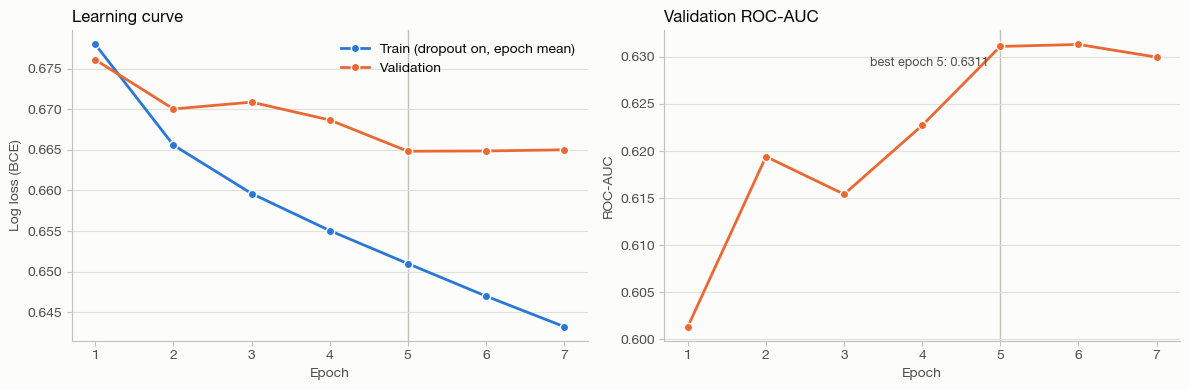

In [12]:
best_row = training_history.set_index("epoch").loc[best_epoch]
with plt.rc_context(VIZ_STYLE):
    fig, (loss_ax, auc_ax) = plt.subplots(1, 2, figsize=(12, 4))
    for column, color, label in [("train_log_loss", BLUE, "Train (dropout on, epoch mean)"),
                                 ("validation_log_loss", ORANGE, "Validation")]:
        loss_ax.plot(training_history["epoch"], training_history[column], color=color, linewidth=2, marker="o",
                     markersize=6, markeredgecolor=SURFACE, label=label)
    loss_ax.set(xlabel="Epoch", ylabel="Log loss (BCE)", title="Learning curve")
    loss_ax.legend(frameon=False, loc="upper right")
    auc_ax.plot(training_history["epoch"], training_history["validation_roc_auc"], color=ORANGE, linewidth=2,
                marker="o", markersize=6, markeredgecolor=SURFACE)
    label_left = best_epoch > training_history["epoch"].median()  # Keep the label inside the axes.
    auc_ax.annotate(f"best epoch {best_epoch}: {best_row['validation_roc_auc']:.4f}",
                    (best_epoch, best_row["validation_roc_auc"]), xytext=(-8 if label_left else 8, -14),
                    textcoords="offset points", ha="right" if label_left else "left", color=INK_2, fontsize=9)
    auc_ax.set(xlabel="Epoch", ylabel="ROC-AUC", title="Validation ROC-AUC")
    for ax in (loss_ax, auc_ax):
        ax.axvline(best_epoch, color=AXIS, linewidth=1, zorder=0)
        ax.set_xticks(training_history["epoch"])
        ax.grid(axis="x", visible=False)
    fig.tight_layout()
    plt.show()

### One validation prediction

One row of the validation split, picked at random with the config seed: the candidate recipe, the model's
prediction and the ground truth. Below it are the user's history windows (1 = most recent) with the last five
recipes of each, their rating and the centered rating that the GRU sees.

In [13]:
validation = data["validation"]
validation_rows = examples[split == "validation"].reset_index(drop=True)
example_index = int(np.random.default_rng(CONFIG.seed).integers(len(validation_rows)))
example = validation_rows.loc[example_index]
p_positive = float(predict_proba(model, {name: values[[example_index]] for name, values in validation.items()})[0])
predicted_label = int(p_positive >= 0.5)
display(pd.Series({
    "user_id": example["user_id"],
    "date": f"{example['date']:%Y-%m-%d}",
    "candidate recipe": f"{example['recipe_id']}: {recipes.loc[example['recipe_idx'], 'name']}",
    "ground truth: source": example["source"],
    "ground truth: rating": "none (sampled)" if pd.isna(example["rating"]) else int(example["rating"]),
    "ground truth: label": int(example["label"]),
    "predicted P(positive)": round(p_positive, 4),
    "predicted label (P >= 0.5)": predicted_label,
    "correct": predicted_label == example["label"],
}, name="validation example").to_frame())

example_history, example_rating, example_window_len = history_windows(
    validation["prior_end"][[example_index]], validation["user_start"][[example_index]],
    validation["mu_before"][[example_index]], first_of_window, observed_recipes, observed_ratings,
    CONFIG.max_windows, CONFIG.t_max)
user_ratings = observed[observed["user_id"] == example["user_id"]].set_index("recipe_idx")
window_rows = []
for window, length in enumerate(example_window_len[0]):
    for step in range(max(0, length - 5), length):
        recipe = example_history[0, window, step]
        window_rows.append({"window": window + 1, "step": step + 1,
                            "date": f"{user_ratings.loc[recipe, 'date']:%Y-%m-%d}",
                            "recipe_id": recipes["recipe_id"].to_numpy()[recipe],
                            "name": recipes["name"].to_numpy()[recipe],
                            "rating": user_ratings.loc[recipe, "rating"],
                            "centered rating (model input)": round(float(example_rating[0, window, step]), 3)})
display(pd.DataFrame(window_rows))


,validation example
user_id,53859
date,2010-09-15
candidate recipe,133387: six minute chocolate cake
ground truth: source,positive (3-5)
ground truth: rating,5
ground truth: label,1
predicted P(positive),0.4883
predicted label (P >= 0.5),0
correct,False


,window,step,date,recipe_id,name,rating,centered rating (model input)
0,1,1,2009-11-27,137686,glazed tzimmes crock pot,5,1.136
1,2,1,2008-06-08,42292,overnight french toast casserole,5,1.136
2,2,2,2008-09-19,213872,baby teething biscuits eggless sugarless,0,-3.864
3,2,3,2008-10-07,59449,mexican tortas de milanesa,5,1.136
4,2,4,2008-12-29,102677,bacon parmesan brussels sprouts,5,1.136
5,3,1,2007-11-23,56927,cheesecake pie,5,1.136
6,4,6,2005-10-12,119507,norwegian fish cakes,4,0.136
7,4,7,2005-10-15,106749,easy egg foo yong,2,-1.864
8,4,8,2005-11-02,16531,crock pot garlic brown sugar chicken,4,0.136
9,4,9,2005-12-04,8757,granny s sugar cookies,4,0.136


## 3.3 Test evaluation

The test split holds each user's last rating plus, when it is positive, its sampled negative.

- `roc_auc` covers every test row. `auc_vs_rated_negatives` is the hard case: recipes the user actually rated,
  liked against not liked. `auc_vs_sampled_negatives` separates liked recipes from recipes the user never rated.
- Baselines: `popularity` scores a candidate by its number of training ratings (ranking only);
  `constant` predicts the training positive rate for every row.

In [14]:
test = data["test"]
test_rows = examples[split == "test"].reset_index(drop=True)
test_probability = predict_proba(model, test)
train_rows = examples[split == "train"]
train_popularity = np.bincount(train_rows.loc[train_rows["source"] != SAMPLED_NEGATIVE, "recipe_idx"],
                               minlength=len(recipes))


def test_report(scores, probabilities):
    labels = test["label"].astype(bool)
    report = {"roc_auc": roc_auc(labels, scores)}
    for column, negative in [("auc_vs_rated_negatives", RATED_NEGATIVE),
                             ("auc_vs_sampled_negatives", SAMPLED_NEGATIVE)]:
        keep = test_rows["source"].isin([POSITIVE, negative]).to_numpy()
        report[column] = roc_auc(labels[keep], scores[keep])
    if probabilities:
        report.update(classification_metrics(labels, scores))
    return report


evaluation = pd.DataFrame({
    "gru_cross_attention": test_report(test_probability, probabilities=True),
    "popularity": test_report(np.log1p(train_popularity[test["candidate"]]), probabilities=False),
    "constant": test_report(np.full(len(test_rows), data["train"]["label"].mean()), probabilities=True),
}).T
print(f"{len(test_rows):,} test rows: " + ", ".join(f"{count:,} {source}"
                                                   for source, count in test_rows["source"].value_counts().items()))
display(evaluation[["log_loss", "roc_auc", "auc_vs_rated_negatives", "auc_vs_sampled_negatives",
                    "accuracy", "precision", "recall", "f1"]].round(4))

20,046 test rows: 9,607 sampled negative, 9,607 positive (3-5), 832 rated negative (0-2)


,log_loss,roc_auc,auc_vs_rated_negatives,auc_vs_sampled_negatives,accuracy,precision,recall,f1
gru_cross_attention,0.6670,0.6246,0.5138,0.6342,0.5867,0.5707,0.5553,0.5629
popularity,NaN,0.5303,0.5059,0.5324,NaN,NaN,NaN,NaN
constant,0.6926,0.5000,0.5000,0.5000,0.5208,0.0000,0.0000,0.0000


## 3.4 Item-embedding cache and serving

After training, `item_emb` is computed once per recipe and stored as `item_cache = {recipe_id: item_emb}`.
Because the cache is built from the final weights, it is never stale. At serving time the user side comes from
the cache: the history is cut into windows, each window's last `t_max` cached embeddings feed the GRU with their
centered ratings, and the profile comes from the history's prices and nutrients. The check below scores every test row through the cache and requires the forward-pass probabilities.

In [15]:
@torch.no_grad()
def encode_catalog(model, batch_size=4096):
    """item_emb for every recipe, in catalog order."""
    model.eval()
    return torch.cat([model.encode_items(torch.arange(start, min(start + batch_size, len(recipes)), device=device)).cpu()
                      for start in range(0, len(recipes), batch_size)])


catalog_embeddings = encode_catalog(model)
item_cache = dict(zip(recipes["recipe_id"].tolist(), catalog_embeddings))  # {recipe_id: item_emb}


@torch.no_grad()
def score_cached(model, embeddings, arrays, rows, candidates, batch_size=256):
    """P(positive) (len(rows), C): candidates[i] scored against the history and profile of arrays row rows[i].
    embeddings are the cached item embeddings in catalog order, the values of item_cache."""
    model.eval()
    scores = []
    for start in range(0, len(rows), batch_size):
        index = rows[start:start + batch_size]
        _, history_idx, history_rating, window_len, profile = to_batch(arrays, index)
        history_emb = embeddings[history_idx.clamp(min=0).cpu()].to(device) * (history_idx >= 0).unsqueeze(-1)
        keys, key_padding_mask = model.user_keys(history_emb, history_rating, window_len, profile)
        candidate_emb = embeddings[torch.from_numpy(candidates[start:start + batch_size])].to(device)
        scores.append(torch.sigmoid(model.score_candidates(candidate_emb, keys, key_padding_mask)).cpu())
    return torch.cat(scores).numpy()


@torch.no_grad()
def rerank_candidates(model, item_cache, user_ratings, candidate_ids, as_of):
    """Rank candidate recipe_ids for one user, most likely positive first, from cached item embeddings.

    user_ratings holds that user's ratings (recipe_id, rating, date). Only days before as_of count: they are cut into
    windows like the training history, with ratings centered on the mean of all of them, and all of them feed the
    profile."""
    model.eval()
    earlier = user_ratings[user_ratings["date"] < as_of].sort_values(["date", "recipe_id"])
    if earlier.empty:
        raise ValueError("The reranker needs at least one rating before as_of.")
    days = earlier["date"].to_numpy().astype("datetime64[D]").astype(np.int64)
    ratings = earlier["rating"].to_numpy(np.float64)
    positions, centered, window_len = history_windows(
        np.array([len(earlier)]), np.array([0]), np.array([ratings.mean()]),
        window_starts(np.zeros(len(days), dtype=np.int64), days, CONFIG.window_gap_days), np.arange(len(earlier)),
        ratings, CONFIG.max_windows, CONFIG.t_max)
    windows, steps = int((window_len > 0).sum()), int(window_len.max())
    positions, centered, window_len = positions[:, :windows, :steps], centered[:, :windows, :steps], window_len[:, :windows]
    earlier_emb = torch.stack([item_cache[recipe_id] for recipe_id in earlier["recipe_id"]])
    history_emb = (earlier_emb[torch.from_numpy(positions).clamp(min=0)]
                   * torch.from_numpy(positions >= 0).unsqueeze(-1)).to(device)
    history_rating = torch.as_tensor(centered, dtype=torch.float32, device=device)
    profile_raw = log_numeric[recipe_index.loc[earlier["recipe_id"]].to_numpy()].mean(0)
    user_profile = torch.as_tensor((profile_raw - profile_mean) / profile_std, dtype=torch.float32, device=device)
    keys, key_padding_mask = model.user_keys(history_emb, history_rating, torch.from_numpy(window_len),
                                             user_profile.unsqueeze(0))
    candidate_emb = torch.stack([item_cache[recipe_id] for recipe_id in candidate_ids]).unsqueeze(0).to(device)
    probability = torch.sigmoid(model.score_candidates(candidate_emb, keys, key_padding_mask))[0].cpu().numpy()
    ranked = pd.DataFrame({"recipe_id": candidate_ids, "p_positive": probability})
    ranked = ranked.merge(recipes[["recipe_id", "name"]], on="recipe_id", how="left")
    return ranked.sort_values("p_positive", ascending=False, ignore_index=True)


cached_probability = score_cached(model, catalog_embeddings, test, np.arange(len(test_rows)),
                                  test["candidate"][:, None])[:, 0]
cache_gap = float(np.abs(cached_probability - test_probability).max())
if cache_gap > 1e-4:
    raise RuntimeError(f"Cached scoring differs from the forward pass by up to {cache_gap:.2e}")
print(f"item_cache holds {len(item_cache):,} recipes × {catalog_embeddings.shape[1]} dims; scoring the test rows "
      f"from it matches the forward pass (max gap {cache_gap:.1e})")

item_cache holds 99,763 recipes × 64 dims; scoring the test rows from it matches the forward pass (max gap 1.2e-07)


### Ranking: HR@10 and NDCG@10

Each test user whose last rating is positive gets a list of 100 candidates: that recipe plus 99 recipes the
user never rated, sampled like the training negatives (∝ popularity). All of them are scored from the cache with
the same history. `hit_rate@10` is the share of users whose held-out recipe lands in the top 10, and random order
gives 0.10. Because the candidates are drawn ∝ popularity, popularity alone has little to go on.

In [16]:
def ranking_metrics(scores, k):
    """scores (users, candidates) with the held-out positive in column 0."""
    rank = 1 + (scores[:, 1:] > scores[:, :1]).sum(1)
    return {f"hit_rate@{k}": np.mean(rank <= k),
            f"ndcg@{k}": np.mean(np.where(rank <= k, 1 / np.log2(rank + 1), 0.0)),
            "mrr": np.mean(1 / rank), "mean_rank": rank.mean()}


ranking_rng = np.random.default_rng(CONFIG.seed + 1)
held_out = np.flatnonzero(test_rows["source"].eq(POSITIVE).to_numpy())  # At most one per user.
held_out_users = test_rows["user_id"].to_numpy()[held_out]
ranking_negatives = sample_unrated(np.repeat(held_out_users, CONFIG.ranking_negatives),
                                   ranking_rng).reshape(len(held_out), -1)
candidate_lists = np.column_stack([test["candidate"][held_out], ranking_negatives])
list_scores = score_cached(model, catalog_embeddings, test, held_out, candidate_lists)
jitter = ranking_rng.random(candidate_lists.shape) * 1e-6  # Breaks ties between equal popularity counts.
ranking = pd.DataFrame({
    "gru_cross_attention": ranking_metrics(list_scores, CONFIG.ndcg_k),
    "popularity": ranking_metrics(np.log1p(train_popularity[candidate_lists]) + jitter, CONFIG.ndcg_k),
    "random": ranking_metrics(ranking_rng.random(candidate_lists.shape), CONFIG.ndcg_k),
}).T
print(f"{len(held_out):,} users, {candidate_lists.shape[1]} candidates each")
display(ranking.round(4))

9,607 users, 100 candidates each


,hit_rate@10,ndcg@10,mrr,mean_rank
gru_cross_attention,0.1966,0.0925,0.0865,37.9696
popularity,0.1480,0.0693,0.0691,47.2856
random,0.1054,0.0476,0.0533,49.9645


### Rerank one user's candidates from the cache

`rerank_candidates` is the serving entry point. For the most active test user it ranks 20 candidates: the
held-out recipe plus 19 of the sampled ones, as of the held-out rating's day.

In [17]:
most_active = int(np.argmax(ratings_per_active_user.reindex(held_out_users).to_numpy()))
example_row = held_out[most_active]
example_user = test_rows.loc[example_row, "user_id"]
example_candidates = recipes["recipe_id"].to_numpy()[candidate_lists[most_active, :20]]
reranked = rerank_candidates(model, item_cache, observed[observed["user_id"] == example_user],
                             example_candidates, as_of=test_rows.loc[example_row, "date"])
reranked["held_out_positive"] = reranked["recipe_id"] == example_candidates[0]
np.testing.assert_allclose(reranked.loc[reranked["held_out_positive"], "p_positive"].item(),
                           test_probability[example_row], atol=1e-5)
print(f"User {example_user} ({ratings_per_active_user[example_user]:,} ratings), as of "
      f"{test_rows.loc[example_row, 'date']:%Y-%m-%d}")
display(reranked.round(4))

User 424680 (3,010 ratings), as of 2013-12-27


,recipe_id,p_positive,name,held_out_positive
0,380918,0.6700,tangy guacamole,False
1,166973,0.6221,twisted sisters creamy cucumber salad,False
2,425992,0.6024,chicken with mushroom curry sauce,False
3,127912,0.5979,mashed red potatoes with horseradish,False
4,31379,0.5659,mom s broccoli green olive salad,False
5,80863,0.5646,crock pot arroz con queso,False
6,42753,0.5335,new york state apple pie,False
7,35042,0.5150,tuna salad a mock one,False
8,74999,0.4972,cuban black bean salad,False
9,510490,0.4914,sticky cinnamon buns 2,True


## Save the reranker

`model_artifacts/gru_xattn_reranker/` holds `model.pt` (weights), `item_cache.pt` (the `{recipe_id: item_emb}`
dictionary), `config.json` (config, vocabulary, normalization statistics, test metrics) and
`training_history.csv`. The catalog tensors are not in `model.pt`: rebuild them from the recipes with the saved
vocabulary and statistics.

In [18]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), ARTIFACT_DIR / "model.pt")
torch.save(item_cache, ARTIFACT_DIR / "item_cache.pt")
(ARTIFACT_DIR / "config.json").write_text(json.dumps({
    "config": asdict(CONFIG), "price_column": PRICE_COLUMN, "nutrient_columns": NUTRIENT_COLUMNS,
    "text_fields": TEXT_FIELDS, "vocabulary": vocabulary,
    "item_log1p_mean": item_mean.tolist(), "item_log1p_std": item_std.tolist(),  # [price, *nutrients]
    "profile_mean": profile_mean.tolist(), "profile_std": profile_std.tolist(),
    "history_rating": "centered",  # rating - mean rating before t, not scaled; windows: config max_windows etc.
    "best_epoch": best_epoch, "test_metrics": evaluation.loc["gru_cross_attention"].to_dict(),
    "test_ranking": ranking.loc["gru_cross_attention"].to_dict(),
}, indent=2))
training_history.to_csv(ARTIFACT_DIR / "training_history.csv", index=False)
restored_cache = torch.load(ARTIFACT_DIR / "item_cache.pt", weights_only=True)
assert restored_cache.keys() == item_cache.keys()
print(f"Saved the reranker and item cache to {ARTIFACT_DIR.resolve()}")

Saved the reranker and item cache to /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/model_artifacts/gru_xattn_reranker
